# Clima vs. atrasos — información de contexto 

Cruza el clima diario descargado con `descargar_clima_openmeteo.py` contra los atrasos de vuelos, para los 20 aeropuertos de origen más importantes.

Antes de correr esto, asegúrate de haber corrido `scripts/descargar_clima_openmeteo.py` (deja el archivo en `data/clima/clima_aeropuertos.csv`).


In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()
PARQUET = "data/parquet/**/*.parquet"
CLIMA = "data/clima/clima_aeropuertos.csv"


## Cruce: % de atrasos según lluvia

`FlightDate` en BTS y `Fecha` en el clima están en el mismo formato (YYYY-MM-DD), así que el cruce es directo por `Origin` + fecha.

Para facilitar la interpretación exploratoria, la precipitación diaria se agrupa en tres categorías:

- Sin lluvia: 0 mm
- Precipitación entre 0 y 5 mm
- Precipitación superior a 5 mm

Estas categorías se utilizan únicamente con fines comparativos dentro del análisis.


In [4]:
atrasos_vs_lluvia = con.execute(f"""
    WITH vuelos AS (
        SELECT Origin, FlightDate, ArrDel15
        FROM parquet_scan('{PARQUET}')
        WHERE ArrDel15 IS NOT NULL
    ),
    clima AS (
        SELECT Origin, Fecha, precipitacion_mm, viento_max_kmh, nieve_cm
        FROM read_csv_auto('{CLIMA}')
    )
    SELECT
        CASE
            WHEN clima.precipitacion_mm = 0 THEN 'Sin lluvia'
            WHEN clima.precipitacion_mm <= 5 THEN 'Lluvia leve (≤5mm)'
            ELSE 'Lluvia fuerte (>5mm)'
        END AS condicion_lluvia,
        COUNT(*) AS vuelos,
        ROUND(100.0 * SUM(CASE WHEN vuelos.ArrDel15 = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_atrasados
    FROM vuelos
    JOIN clima ON vuelos.Origin = clima.Origin AND vuelos.FlightDate = clima.Fecha
    GROUP BY condicion_lluvia
    ORDER BY pct_atrasados
""").fetchdf()

atrasos_vs_lluvia


,condicion_lluvia,vuelos,pct_atrasados
0,Sin lluvia,5897439,18.57
1,Lluvia leve (≤5mm),3068762,25.34
2,Lluvia fuerte (>5mm),1574184,33.84


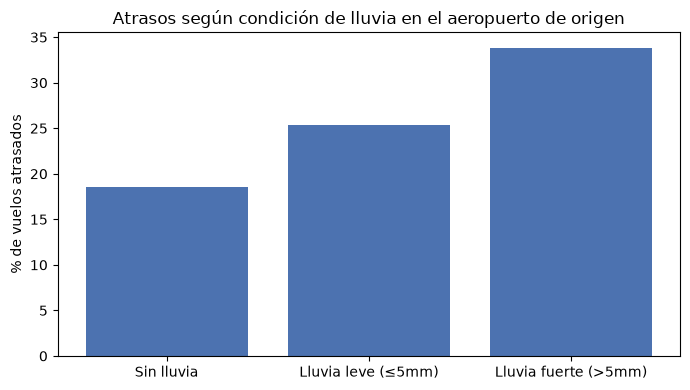

In [5]:
plt.figure(figsize=(7, 4))
plt.bar(atrasos_vs_lluvia["condicion_lluvia"], atrasos_vs_lluvia["pct_atrasados"], color="#4C72B0")
plt.ylabel("% de vuelos atrasados")
plt.title("Atrasos según condición de lluvia en el aeropuerto de origen")
plt.tight_layout()
plt.show()


## Cruce: % de atrasos según viento fuerte

Mismo patrón, ahora con viento

Viento < 40 km/h

Viento ≥ 40 km/h

In [7]:
atrasos_vs_viento = con.execute(f"""
    WITH vuelos AS (
        SELECT Origin, FlightDate, ArrDel15
        FROM parquet_scan('{PARQUET}')
        WHERE ArrDel15 IS NOT NULL
    ),
    clima AS (
        SELECT Origin, Fecha, viento_max_kmh
        FROM read_csv_auto('{CLIMA}')
    )
    SELECT
        CASE
            WHEN clima.viento_max_kmh >= 40 THEN 'Viento ≥40 km/h'
            ELSE 'Viento <40 km/h'
        END AS condicion_viento,
        COUNT(*) AS vuelos,
        ROUND(
            100.0 * SUM(CASE WHEN vuelos.ArrDel15 = 1 THEN 1 ELSE 0 END) / COUNT(*),
            2
        ) AS pct_atrasados
    FROM vuelos
    JOIN clima
        ON vuelos.Origin = clima.Origin
        AND vuelos.FlightDate = clima.Fecha
    GROUP BY condicion_viento
    ORDER BY pct_atrasados
""").fetchdf()

atrasos_vs_viento

,condicion_viento,vuelos,pct_atrasados
0,Viento <40 km/h,10472673,22.75
1,Viento ≥40 km/h,67712,34.77


## Conclusión para el documento

El cruce entre la información meteorológica y los vuelos permitió identificar diferencias en la proporción de atrasos según las condiciones de precipitación y viento.

En los días sin lluvia, el 18,57% de los vuelos presentó atrasos, mientras que este porcentaje aumentó a 25,34% cuando la precipitación diaria fue de hasta 5 mm y a 33,84% cuando superó los 5 mm. Esto representa una diferencia de 15,27 puntos porcentuales entre los días sin lluvia y los días con mayor precipitación.

De manera similar, los vuelos asociados a días con velocidades máximas de viento inferiores a 40 km/h presentaron un 22,75% de atrasos, mientras que en días con viento igual o superior a 40 km/h el porcentaje aumentó a 34,77%, una diferencia de 12,02 puntos porcentuales.

Estos resultados muestran una asociación descriptiva entre condiciones meteorológicas adversas y una mayor proporción de vuelos atrasados. Sin embargo, el análisis no permite establecer una relación causal, ya que también pueden intervenir otros factores como la aerolínea, el aeropuerto, la ruta, la temporada, el horario y la congestión operacional.

Por tanto, el clima constituye una fuente de información contextual relevante para complementar el dataset BTS. Como mejora futura, estas variables meteorológicas podrían incorporarse directamente al modelo predictivo.
